#                                 Regresi - 1D

# Load Data

In [1]:
import pandas as pd
import os

In [2]:

file_name = "diabetes_dataset"
root_folder = f'regresi/one-d/{file_name}/' 
os.makedirs(root_folder, exist_ok=True)

df = pd.read_csv('sample_data/'+file_name+'.csv')

#buang kolom tidak dibutuhkan
df.drop(columns=['diagnosed_diabetes'], inplace=True)

print("Sebulum DROP nan : " + str(df.shape) )
df = df.dropna() #Drop Nan
print("Setelah DROP nan : " + str(df.shape) )



Sebulum DROP nan : (100000, 30)
Setelah DROP nan : (100000, 30)


In [3]:
df.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,239,41,160,145,136,236,6.36,8.18,29.6,Type 2
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,116,55,50,30,93,150,2.00,5.63,23.0,No Diabetes
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,213,66,99,36,118,195,5.07,7.51,44.7,Type 2
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,171,50,79,140,139,253,5.28,9.03,38.2,Type 2
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,210,52,125,160,137,184,12.74,7.20,23.5,Type 2


#### LabelEncoder

In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
#labeling
df['label_gender']            = le.fit_transform(df['gender'])
df['label_ethnicity']         = le.fit_transform(df['ethnicity'])
df['label_income_level']      = le.fit_transform(df['income_level'])
df['label_education_level']   = le.fit_transform(df['education_level'])
df['label_employment_status'] = le.fit_transform(df['employment_status'])
df['label_smoking_status']    = le.fit_transform(df['smoking_status'])



df.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,label_gender,label_ethnicity,label_income_level,label_education_level,label_employment_status,label_smoking_status
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,6.36,8.18,29.6,Type 2,1,0,2,1,0,2
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,2.00,5.63,23.0,No Diabetes,0,4,3,1,0,1
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,5.07,7.51,44.7,Type 2,1,2,3,1,3,2
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,5.28,9.03,38.2,Type 2,0,1,1,1,1,2
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,12.74,7.20,23.5,Type 2,1,4,3,0,1,2


#### Scaler

In [5]:
from sklearn.preprocessing import MinMaxScaler
import joblib

# Contoh: buat dan fit scaler
scaler = MinMaxScaler()
cols = [
    'label_gender', 
    'label_ethnicity', 
    'label_income_level',
    'label_education_level',
    'label_employment_status', 
    'label_smoking_status',
    #--------------------------
    'age',
    'physical_activity_minutes_per_week',
    'diet_score',
    'sleep_hours_per_day',
    'glucose_postprandial',
    'insulin_level',
    'hba1c',
    'diabetes_risk_score'
]

# Dictionary untuk menyimpan hasil transformasi
scaled_data = {}

# Loop untuk setiap kolom
for col in cols:
    scaler = MinMaxScaler()
    df[[col]] = scaler.fit_transform(df[[col]])  # scaling per kolom
    joblib.dump(scaler, os.path.join(root_folder, f'scaler_{col}.pkl'))
    scaled_data[col] = scaler
    print(f"✅ Scaler for '{col}' saved as scaler_{col}.pkl")

print("\nAll individual scalers saved successfully!")

✅ Scaler for 'label_gender' saved as scaler_label_gender.pkl
✅ Scaler for 'label_ethnicity' saved as scaler_label_ethnicity.pkl
✅ Scaler for 'label_income_level' saved as scaler_label_income_level.pkl
✅ Scaler for 'label_education_level' saved as scaler_label_education_level.pkl
✅ Scaler for 'label_employment_status' saved as scaler_label_employment_status.pkl
✅ Scaler for 'label_smoking_status' saved as scaler_label_smoking_status.pkl
✅ Scaler for 'age' saved as scaler_age.pkl
✅ Scaler for 'physical_activity_minutes_per_week' saved as scaler_physical_activity_minutes_per_week.pkl
✅ Scaler for 'diet_score' saved as scaler_diet_score.pkl
✅ Scaler for 'sleep_hours_per_day' saved as scaler_sleep_hours_per_day.pkl
✅ Scaler for 'glucose_postprandial' saved as scaler_glucose_postprandial.pkl
✅ Scaler for 'insulin_level' saved as scaler_insulin_level.pkl
✅ Scaler for 'hba1c' saved as scaler_hba1c.pkl
✅ Scaler for 'diabetes_risk_score' saved as scaler_diabetes_risk_score.pkl

All individual sc

In [6]:
df.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,label_gender,label_ethnicity,label_income_level,label_education_level,label_employment_status,label_smoking_status
0,0.555556,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,0.258103,0.57,...,0.144275,0.720690,0.417054,Type 2,0.5,0.00,0.50,0.333333,0.000000,1.0
1,0.416667,Female,White,Highschool,Middle,Employed,Former,1,0.171669,0.67,...,0.000000,0.281034,0.314729,No Diabetes,0.0,1.00,0.75,0.333333,0.000000,0.5
2,0.583333,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,0.068427,0.64,...,0.101588,0.605172,0.651163,Type 2,0.5,0.50,0.75,0.333333,1.000000,1.0
3,0.777778,Female,Black,Highschool,Low,Retired,Never,0,0.058824,0.34,...,0.108537,0.867241,0.550388,Type 2,0.0,0.25,0.25,0.333333,0.333333,1.0
4,0.388889,Male,White,Graduate,Middle,Retired,Never,1,0.130852,0.72,...,0.355394,0.551724,0.322481,Type 2,0.5,1.00,0.75,0.000000,0.333333,1.0


#### Mapping label

In [7]:
import json
mapping_dicts = {}

cols = [
    'gender',
    'ethnicity',
    'education_level',
    'income_level',
    'employment_status',
    'smoking_status'
]

for col in cols:
    label_col = f"label_{col}"
    mapping_dicts[col] = dict(zip(df[col], df[label_col]))


with open(root_folder + 'label_mappings.json', 'w') as f:
    json.dump(mapping_dicts, f, indent=2)

rows = []
for col, mapping in mapping_dicts.items():
    for k, v in mapping.items():
        rows.append({'feature': col, 'original_value': k, 'label_value': v})

mapping_table = pd.DataFrame(rows)
mapping_table

,feature,original_value,label_value
0,gender,Male,0.500000
1,gender,Female,0.000000
2,gender,Other,1.000000
3,ethnicity,Asian,0.000000
4,ethnicity,White,1.000000
5,ethnicity,Hispanic,0.500000
6,ethnicity,Black,0.250000
7,ethnicity,Other,0.750000
8,education_level,Highschool,0.333333
9,education_level,Graduate,0.000000


#### Select Kolom To Trian

In [8]:
col_target = 'diabetes_risk_score'
cols = [
    'label_gender', 
    'label_ethnicity', 
    'label_income_level',
    'label_education_level',
    'label_employment_status', 
    'label_smoking_status',
    #--------------------------
    'age',
    'physical_activity_minutes_per_week',
    'diet_score',
    'sleep_hours_per_day',
    'glucose_postprandial',
    'insulin_level',
    'hba1c',
    #------------------------
    col_target
]
df = df[cols].copy()

df.head()

,label_gender,label_ethnicity,label_income_level,label_education_level,label_employment_status,label_smoking_status,age,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score
0,0.5,0.00,0.50,0.333333,0.000000,1.0,0.555556,0.258103,0.57,0.700000,0.764977,0.144275,0.720690,0.417054
1,0.0,1.00,0.75,0.333333,0.000000,0.5,0.416667,0.171669,0.67,0.500000,0.368664,0.000000,0.281034,0.314729
2,0.5,0.50,0.75,0.333333,1.000000,1.0,0.583333,0.068427,0.64,1.000000,0.576037,0.101588,0.605172,0.651163
3,0.0,0.25,0.25,0.333333,0.333333,1.0,0.777778,0.058824,0.34,0.514286,0.843318,0.108537,0.867241,0.550388
4,0.5,1.00,0.75,0.000000,0.333333,1.0,0.388889,0.130852,0.72,0.628571,0.525346,0.355394,0.551724,0.322481


# Data Load To Train

#### select Future to traian

In [9]:
feature_cols = [
        'label_gender', 
        #'label_ethnicity', 
        #'label_income_level',
        #'label_education_level',
        #'label_employment_status', 
        #'label_smoking_status',
        #--------------------------
        'age',
        'physical_activity_minutes_per_week',
        'diet_score',
        'sleep_hours_per_day',
        'glucose_postprandial',
        'insulin_level',
        'hba1c',
    ]
target_cols  = col_target

#### Split data

In [10]:
import torch
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Misal df sudah berisi semua data
# Pisahkan fitur dan target
feature_cols = feature_cols
target_cols = target_cols

# Pisahkan train-test (stratify opsional jika masih punya kolom 'diabetes_stage')
X_train, X_test = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)


#### DataLoader

In [11]:
from data_set import Regression1DDataset

# Buat dataset dengan class kamu
train_dataset = Regression1DDataset(X_train, feature_cols, target_cols, normalize=False)
test_dataset  = Regression1DDataset(X_test, feature_cols, target_cols, normalize=False)

# Buat DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=True)

# Cek contoh batch
for X, y in train_loader:
    print("X shape:", X.shape)
    print("y shape:", y.shape)
    print(X[:3])  # contoh fitur
    print(y[:3])  # contoh label
    break

X shape: torch.Size([32, 8])
y shape: torch.Size([32, 1])
tensor([[0.5000, 0.4722, 0.0480, 0.6000, 0.8000, 0.2166, 0.3187, 0.2828],
        [0.5000, 0.4444, 0.0420, 0.5400, 0.5571, 0.3871, 0.2578, 0.5138],
        [0.5000, 0.0000, 0.1777, 0.1600, 0.6714, 0.5253, 0.0288, 0.5190]])
tensor([[0.6558],
        [0.4899],
        [0.2775]])


# Config

In [12]:
from jcopdl.callback import Callback, set_config
config = set_config({
    "input_dim"      : len(test_dataset.X[0]),
    "hidden_dims"    : [ 32,16,8,4],
    "output_dim"     : len(test_dataset.y[0]),
    "dropout"        : 0.0,
    "activation"     : "relu",
    "early_stop_patience" : 10,
    "col_target"     : col_target,
    "feature_cols"   : feature_cols
})
config

Config(activation=relu, col_target=diabetes_risk_score, dropout=0.0, early_stop_patience=10, feature_cols=['label_gender', 'age', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'glucose_postprandial', 'insulin_level', 'hba1c'], hidden_dims=[32, 16, 8, 4], input_dim=8, output_dim=1)

# MCOC

#### Model - Criterion - Optimizer - Callback

In [13]:
from class_lib import Model1DPure
from torch import optim, nn
from jcopdl.callback import Callback
import torch.optim as optim

#Model
model = Model1DPure(input_dim=config.input_dim, hidden_dims=config.hidden_dims, output_dim=config.output_dim, dropout=config.dropout, activation=config.activation).to(device)

#Criterion
criterion = nn.MSELoss()

# --- Pilihan Optimizer ---
# AdamW
optimizer_adamw = optim.AdamW(model.parameters(), lr=0.001)
# Adam
optimizer_adam = optim.Adam(model.parameters(), lr=0.001)
# SGD (Stochastic Gradient Descent)
optimizer_sgd = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
# RMSprop
optimizer_rmsprop = optim.RMSprop(model.parameters(), lr=0.001, momentum=0.9)
# Adagrad
optimizer_adagrad = optim.Adagrad(model.parameters(), lr=0.01)
# Adadelta
optimizer_adadelta = optim.Adadelta(model.parameters(), lr=0.1)
# ASGD (Averaged SGD)
optimizer_asgd = optim.ASGD(model.parameters(), lr=0.01)

# --- Contoh cara memilih salah satu ---
optim = optimizer_sgd  # misalnya kita pakai RAdam

#Callback
callback = Callback(model, config, outdir=root_folder,early_stop_patience=config.early_stop_patience)

#### Visualisasi Model

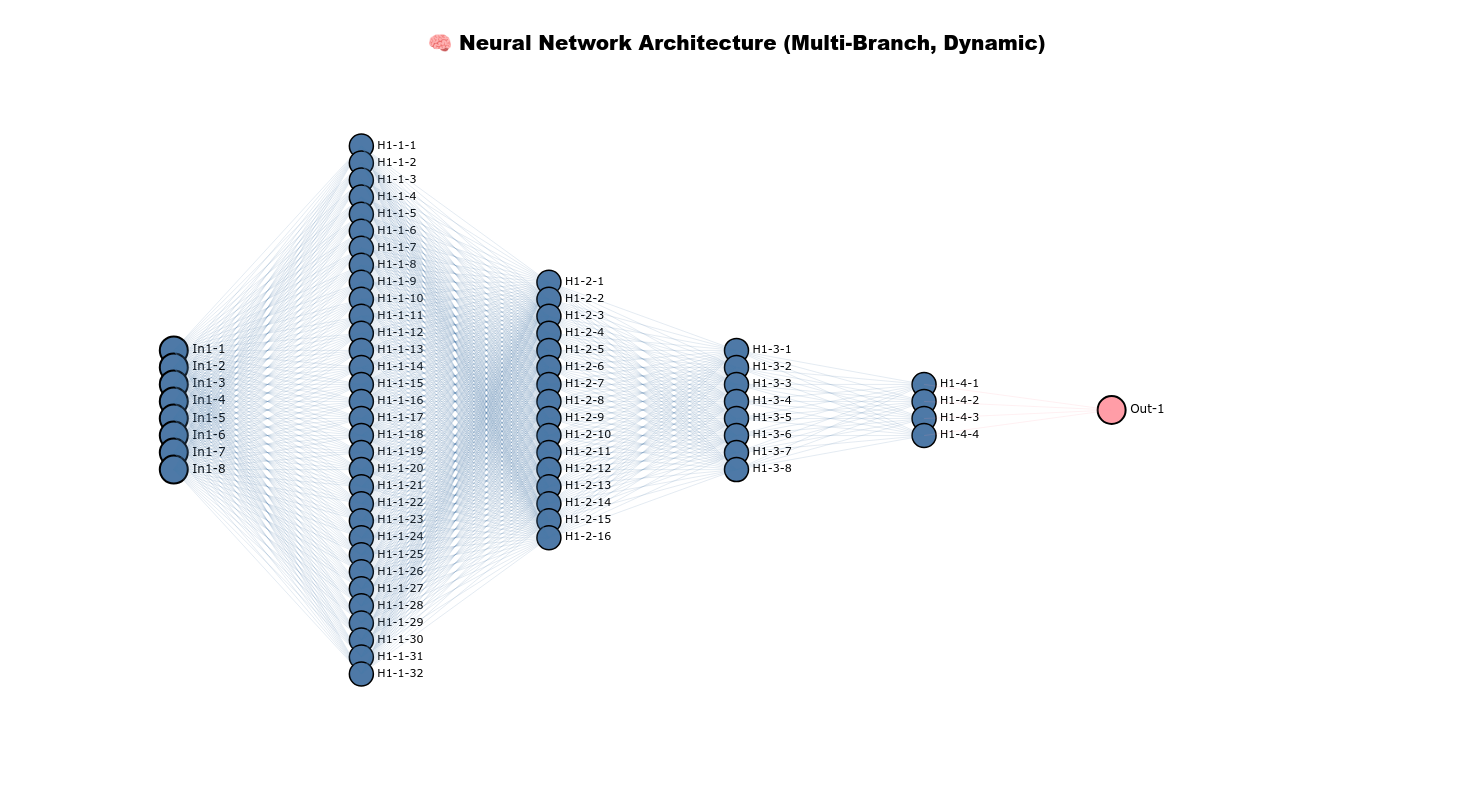

In [14]:
from visualization import plot_dynamic_multi_input_network
plot_dynamic_multi_input_network(
    input_dims=[config.input_dim],
    hidden_dims_per_branch=[
        config.hidden_dims
    ],
    combined_dims=None,
    output_dim=config.output_dim,
    figsize=(1000, 800)
)


# Training


─────────────────────────────────────────────────── 🚀 EPOCH 1 ────────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2774.71it/s]


    Summary (Regression)     
┏━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃   Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩
│ LOSS   │  0.0211 │ 0.0197 │
│ MAE    │  0.1143 │ 0.1124 │
│ RMSE   │  0.1451 │ 0.1405 │
│ R2     │ -0.0687 │ 0.0044 │
└────────┴─────────┴────────┘

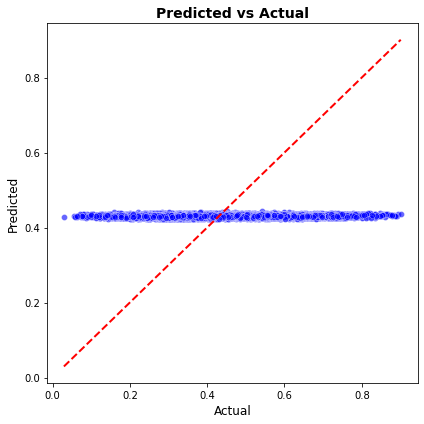


Epoch     1
Train_cost  = 0.0211 | Test_cost  = 0.0197 | Train_score = -0.0687 | Test_score = 0.0044 |


─────────────────────────────────────────────────── 🚀 EPOCH 2 ────────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2641.46it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0195 │ 0.0196 │
│ MAE    │ 0.1111 │ 0.1122 │
│ RMSE   │ 0.1398 │ 0.1400 │
│ R2     │ 0.0089 │ 0.0115 │
└────────┴────────┴────────┘

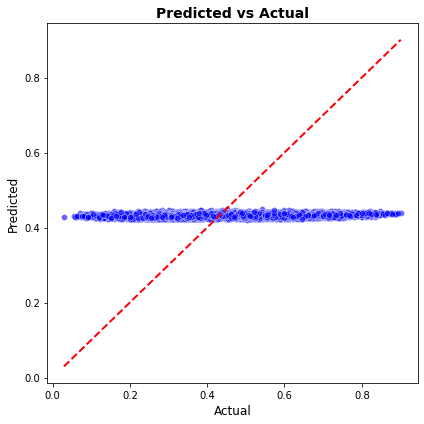


Epoch     2
Train_cost  = 0.0195 | Test_cost  = 0.0196 | Train_score = 0.0089 | Test_score = 0.0115 |


─────────────────────────────────────────────────── 🚀 EPOCH 3 ────────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2471.95it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0193 │ 0.0193 │
│ MAE    │ 0.1105 │ 0.1104 │
│ RMSE   │ 0.1391 │ 0.1390 │
│ R2     │ 0.0191 │ 0.0263 │
└────────┴────────┴────────┘

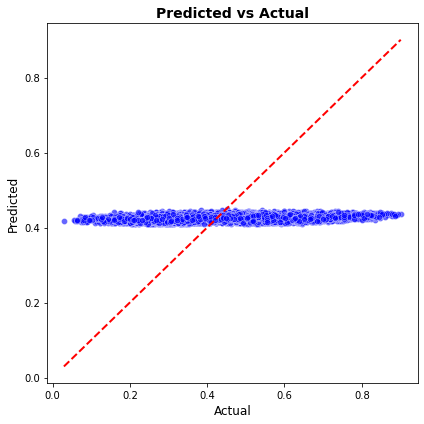


Epoch     3
Train_cost  = 0.0193 | Test_cost  = 0.0193 | Train_score = 0.0191 | Test_score = 0.0263 |


─────────────────────────────────────────────────── 🚀 EPOCH 4 ────────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2384.73it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0190 │ 0.0188 │
│ MAE    │ 0.1094 │ 0.1090 │
│ RMSE   │ 0.1378 │ 0.1373 │
│ R2     │ 0.0364 │ 0.0502 │
└────────┴────────┴────────┘

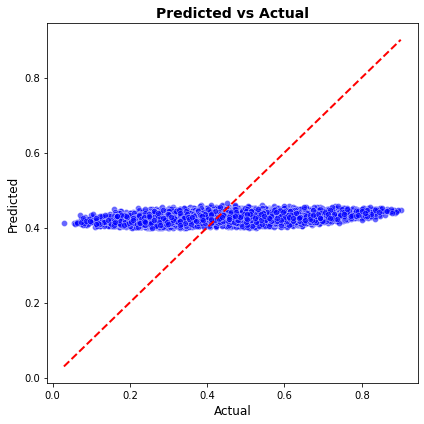


Epoch     4
Train_cost  = 0.0190 | Test_cost  = 0.0188 | Train_score = 0.0364 | Test_score = 0.0502 |


─────────────────────────────────────────────────── 🚀 EPOCH 5 ────────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2469.58it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0183 │ 0.0179 │
│ MAE    │ 0.1071 │ 0.1062 │
│ RMSE   │ 0.1352 │ 0.1337 │
│ R2     │ 0.0722 │ 0.0993 │
└────────┴────────┴────────┘

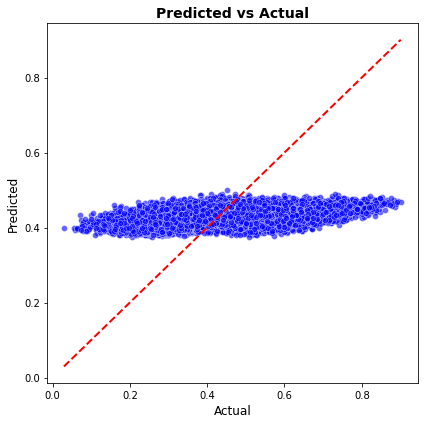


Epoch     5
Train_cost  = 0.0183 | Test_cost  = 0.0179 | Train_score = 0.0722 | Test_score = 0.0993 |


─────────────────────────────────────────────────── 🚀 EPOCH 6 ────────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2559.31it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0169 │ 0.0161 │
│ MAE    │ 0.1024 │ 0.1006 │
│ RMSE   │ 0.1300 │ 0.1269 │
│ R2     │ 0.1427 │ 0.1880 │
└────────┴────────┴────────┘

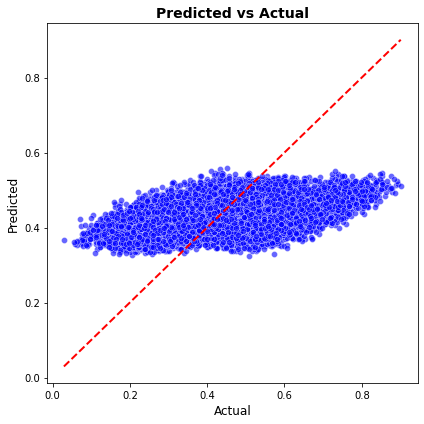


Epoch     6
Train_cost  = 0.0169 | Test_cost  = 0.0161 | Train_score = 0.1427 | Test_score = 0.1880 |


─────────────────────────────────────────────────── 🚀 EPOCH 7 ────────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2563.82it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0150 │ 0.0145 │
│ MAE    │ 0.0955 │ 0.0923 │
│ RMSE   │ 0.1225 │ 0.1204 │
│ R2     │ 0.2381 │ 0.2690 │
└────────┴────────┴────────┘

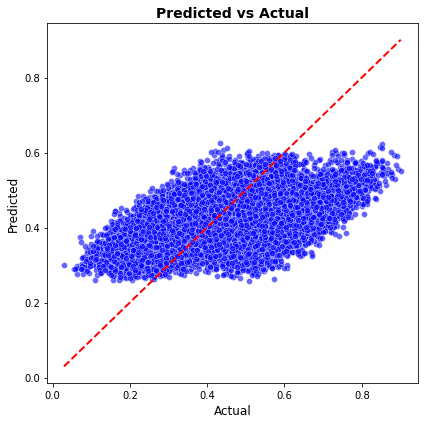


Epoch     7
Train_cost  = 0.0150 | Test_cost  = 0.0145 | Train_score = 0.2381 | Test_score = 0.2690 |


─────────────────────────────────────────────────── 🚀 EPOCH 8 ────────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2454.07it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0138 │ 0.0136 │
│ MAE    │ 0.0914 │ 0.0900 │
│ RMSE   │ 0.1176 │ 0.1168 │
│ R2     │ 0.2985 │ 0.3122 │
└────────┴────────┴────────┘

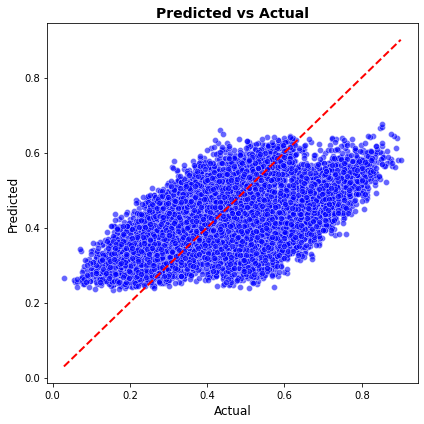


Epoch     8
Train_cost  = 0.0138 | Test_cost  = 0.0136 | Train_score = 0.2985 | Test_score = 0.3122 |


─────────────────────────────────────────────────── 🚀 EPOCH 9 ────────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2446.39it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0131 │ 0.0130 │
│ MAE    │ 0.0895 │ 0.0893 │
│ RMSE   │ 0.1146 │ 0.1140 │
│ R2     │ 0.3343 │ 0.3448 │
└────────┴────────┴────────┘

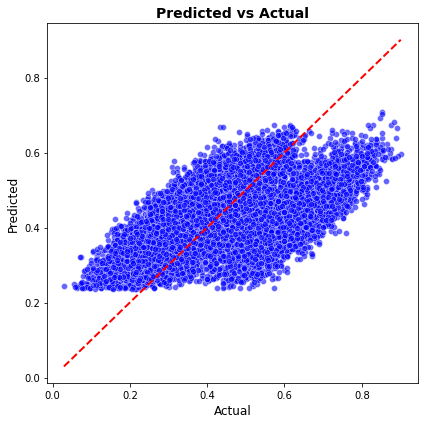


Epoch     9
Train_cost  = 0.0131 | Test_cost  = 0.0130 | Train_score = 0.3343 | Test_score = 0.3448 |


─────────────────────────────────────────────────── 🚀 EPOCH 10 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2364.27it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0126 │ 0.0125 │
│ MAE    │ 0.0880 │ 0.0867 │
│ RMSE   │ 0.1120 │ 0.1118 │
│ R2     │ 0.3632 │ 0.3701 │
└────────┴────────┴────────┘

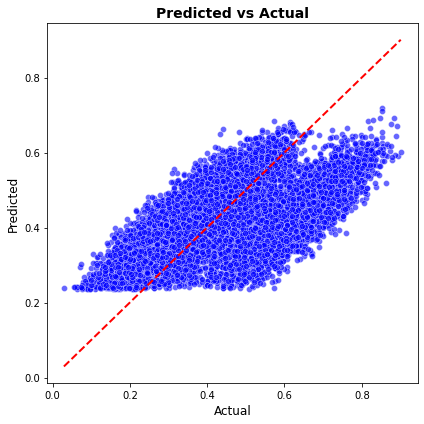


Epoch    10
Train_cost  = 0.0126 | Test_cost  = 0.0125 | Train_score = 0.3632 | Test_score = 0.3701 |


─────────────────────────────────────────────────── 🚀 EPOCH 11 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2382.05it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0121 │ 0.0120 │
│ MAE    │ 0.0867 │ 0.0862 │
│ RMSE   │ 0.1099 │ 0.1097 │
│ R2     │ 0.3870 │ 0.3935 │
└────────┴────────┴────────┘

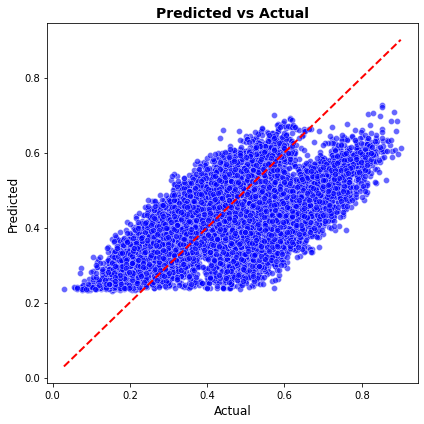


Epoch    11
Train_cost  = 0.0121 | Test_cost  = 0.0120 | Train_score = 0.3870 | Test_score = 0.3935 |


─────────────────────────────────────────────────── 🚀 EPOCH 12 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2514.27it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0117 │ 0.0117 │
│ MAE    │ 0.0855 │ 0.0873 │
│ RMSE   │ 0.1081 │ 0.1081 │
│ R2     │ 0.4072 │ 0.4108 │
└────────┴────────┴────────┘

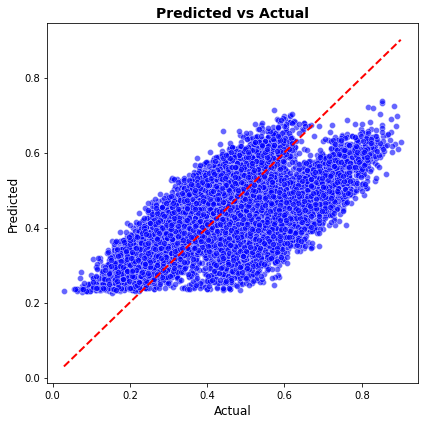


Epoch    12
Train_cost  = 0.0117 | Test_cost  = 0.0117 | Train_score = 0.4072 | Test_score = 0.4108 |


─────────────────────────────────────────────────── 🚀 EPOCH 13 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2418.77it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0114 │ 0.0114 │
│ MAE    │ 0.0845 │ 0.0859 │
│ RMSE   │ 0.1067 │ 0.1069 │
│ R2     │ 0.4226 │ 0.4242 │
└────────┴────────┴────────┘

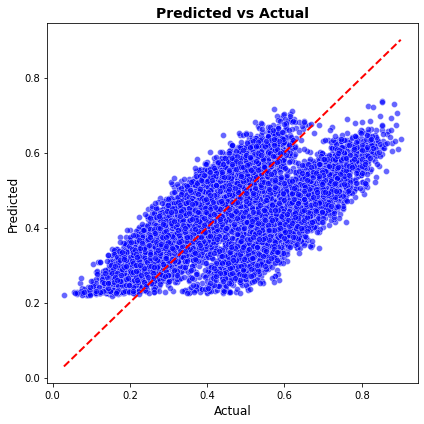


Epoch    13
Train_cost  = 0.0114 | Test_cost  = 0.0114 | Train_score = 0.4226 | Test_score = 0.4242 |


─────────────────────────────────────────────────── 🚀 EPOCH 14 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2470.42it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0112 │ 0.0113 │
│ MAE    │ 0.0838 │ 0.0824 │
│ RMSE   │ 0.1058 │ 0.1063 │
│ R2     │ 0.4323 │ 0.4302 │
└────────┴────────┴────────┘

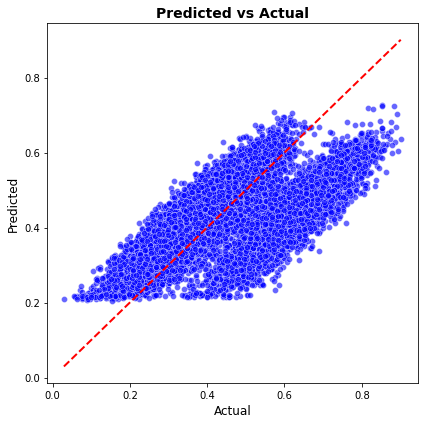


Epoch    14
Train_cost  = 0.0112 | Test_cost  = 0.0113 | Train_score = 0.4323 | Test_score = 0.4302 |


─────────────────────────────────────────────────── 🚀 EPOCH 15 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2491.54it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0111 │ 0.0112 │
│ MAE    │ 0.0834 │ 0.0825 │
│ RMSE   │ 0.1053 │ 0.1059 │
│ R2     │ 0.4375 │ 0.4343 │
└────────┴────────┴────────┘

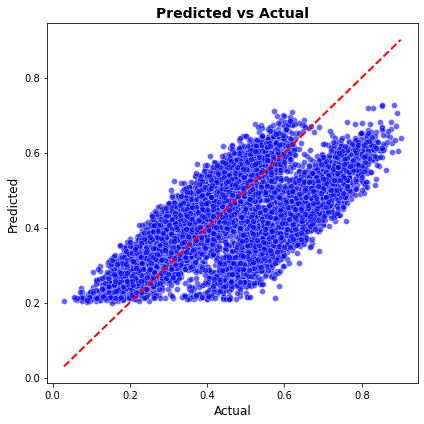


Epoch    15
Train_cost  = 0.0111 | Test_cost  = 0.0112 | Train_score = 0.4375 | Test_score = 0.4343 |


─────────────────────────────────────────────────── 🚀 EPOCH 16 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2672.22it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0112 │
│ MAE    │ 0.0833 │ 0.0836 │
│ RMSE   │ 0.1051 │ 0.1057 │
│ R2     │ 0.4397 │ 0.4371 │
└────────┴────────┴────────┘

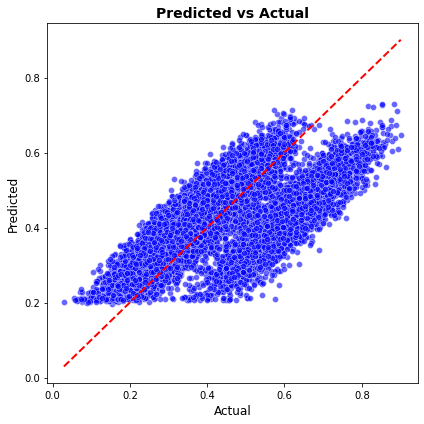


Epoch    16
Train_cost  = 0.0110 | Test_cost  = 0.0112 | Train_score = 0.4397 | Test_score = 0.4371 |


─────────────────────────────────────────────────── 🚀 EPOCH 17 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2488.50it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0112 │
│ MAE    │ 0.0832 │ 0.0825 │
│ RMSE   │ 0.1050 │ 0.1057 │
│ R2     │ 0.4408 │ 0.4370 │
└────────┴────────┴────────┘

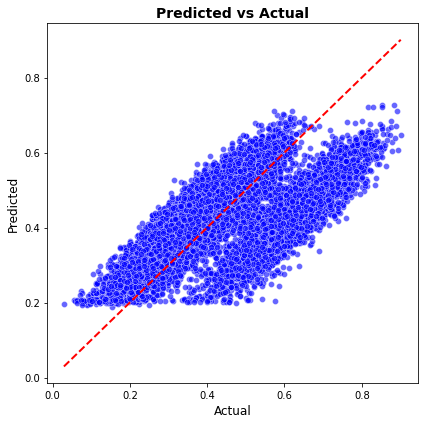


Epoch    17
Train_cost  = 0.0110 | Test_cost  = 0.0112 | Train_score = 0.4408 | Test_score = 0.4370 |
==> EarlyStop patience =  1 | Best test_score: 0.4371


─────────────────────────────────────────────────── 🚀 EPOCH 18 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2559.99it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0111 │
│ MAE    │ 0.0832 │ 0.0838 │
│ RMSE   │ 0.1049 │ 0.1056 │
│ R2     │ 0.4413 │ 0.4383 │
└────────┴────────┴────────┘

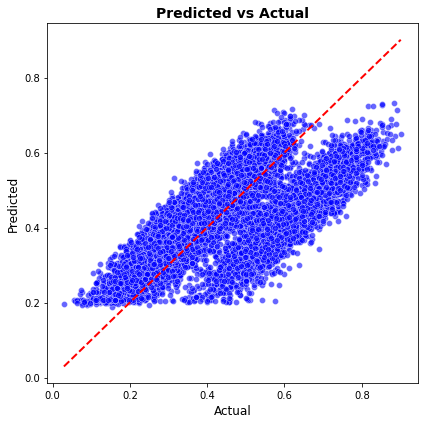


Epoch    18
Train_cost  = 0.0110 | Test_cost  = 0.0111 | Train_score = 0.4413 | Test_score = 0.4383 |


─────────────────────────────────────────────────── 🚀 EPOCH 19 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2302.20it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0111 │
│ MAE    │ 0.0832 │ 0.0841 │
│ RMSE   │ 0.1049 │ 0.1055 │
│ R2     │ 0.4418 │ 0.4386 │
└────────┴────────┴────────┘

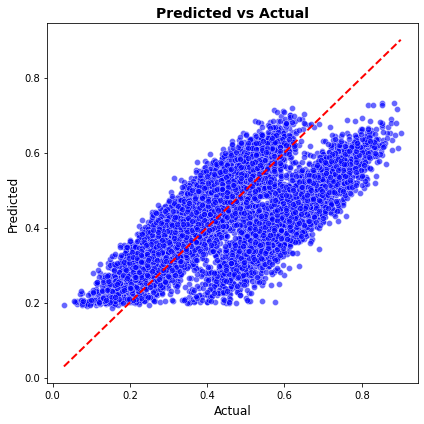


Epoch    19
Train_cost  = 0.0110 | Test_cost  = 0.0111 | Train_score = 0.4418 | Test_score = 0.4386 |


─────────────────────────────────────────────────── 🚀 EPOCH 20 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2563.78it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0111 │
│ MAE    │ 0.0831 │ 0.0849 │
│ RMSE   │ 0.1049 │ 0.1055 │
│ R2     │ 0.4421 │ 0.4385 │
└────────┴────────┴────────┘

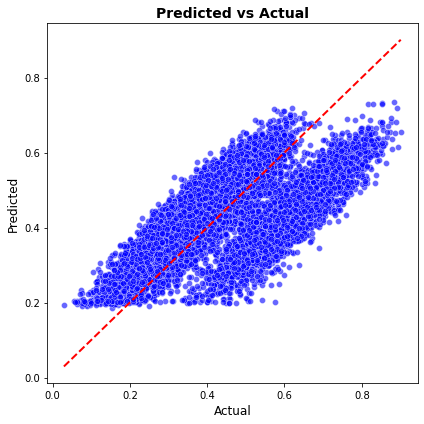


Epoch    20
Train_cost  = 0.0110 | Test_cost  = 0.0111 | Train_score = 0.4421 | Test_score = 0.4385 |


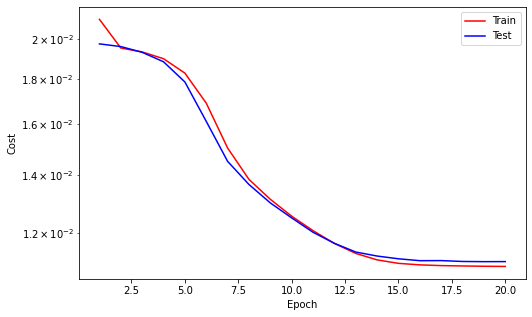

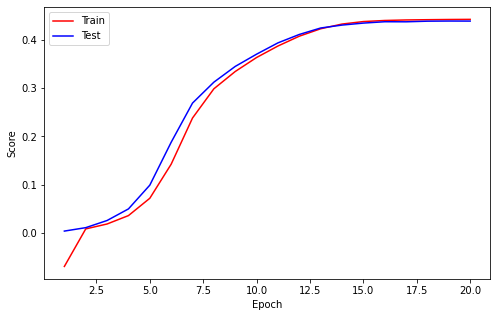

==> EarlyStop patience =  1 | Best test_score: 0.4386


─────────────────────────────────────────────────── 🚀 EPOCH 21 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2469.93it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0111 │
│ MAE    │ 0.0831 │ 0.0844 │
│ RMSE   │ 0.1049 │ 0.1055 │
│ R2     │ 0.4421 │ 0.4388 │
└────────┴────────┴────────┘

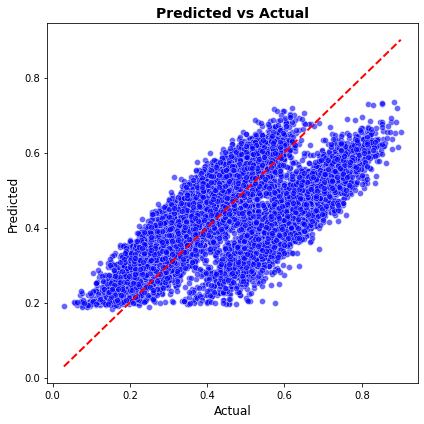


Epoch    21
Train_cost  = 0.0110 | Test_cost  = 0.0111 | Train_score = 0.4421 | Test_score = 0.4388 |


─────────────────────────────────────────────────── 🚀 EPOCH 22 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2594.28it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0112 │
│ MAE    │ 0.0831 │ 0.0814 │
│ RMSE   │ 0.1048 │ 0.1058 │
│ R2     │ 0.4425 │ 0.4361 │
└────────┴────────┴────────┘

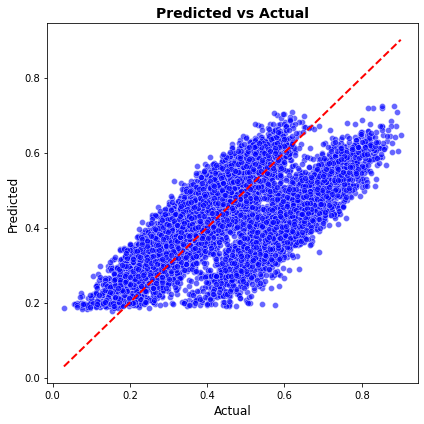


Epoch    22
Train_cost  = 0.0110 | Test_cost  = 0.0112 | Train_score = 0.4425 | Test_score = 0.4361 |
==> EarlyStop patience =  1 | Best test_score: 0.4388


─────────────────────────────────────────────────── 🚀 EPOCH 23 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2631.26it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0111 │
│ MAE    │ 0.0831 │ 0.0840 │
│ RMSE   │ 0.1048 │ 0.1055 │
│ R2     │ 0.4424 │ 0.4390 │
└────────┴────────┴────────┘

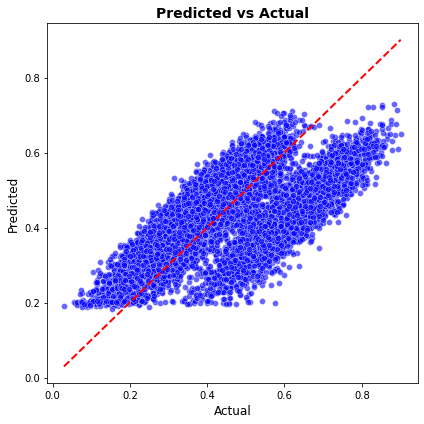


Epoch    23
Train_cost  = 0.0110 | Test_cost  = 0.0111 | Train_score = 0.4424 | Test_score = 0.4390 |


─────────────────────────────────────────────────── 🚀 EPOCH 24 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2460.87it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0112 │
│ MAE    │ 0.0831 │ 0.0821 │
│ RMSE   │ 0.1048 │ 0.1056 │
│ R2     │ 0.4426 │ 0.4378 │
└────────┴────────┴────────┘

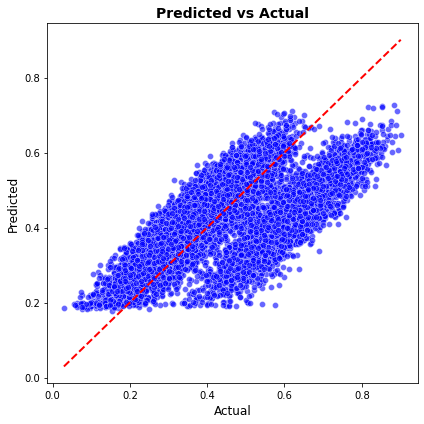


Epoch    24
Train_cost  = 0.0110 | Test_cost  = 0.0112 | Train_score = 0.4426 | Test_score = 0.4378 |
==> EarlyStop patience =  1 | Best test_score: 0.4390


─────────────────────────────────────────────────── 🚀 EPOCH 25 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2500.59it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0112 │
│ MAE    │ 0.0831 │ 0.0815 │
│ RMSE   │ 0.1049 │ 0.1057 │
│ R2     │ 0.4422 │ 0.4369 │
└────────┴────────┴────────┘

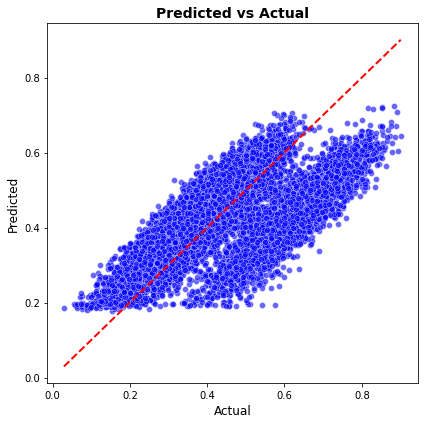


Epoch    25
Train_cost  = 0.0110 | Test_cost  = 0.0112 | Train_score = 0.4422 | Test_score = 0.4369 |
==> EarlyStop patience =  2 | Best test_score: 0.4390


─────────────────────────────────────────────────── 🚀 EPOCH 26 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2639.22it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0111 │
│ MAE    │ 0.0831 │ 0.0855 │
│ RMSE   │ 0.1048 │ 0.1055 │
│ R2     │ 0.4425 │ 0.4385 │
└────────┴────────┴────────┘

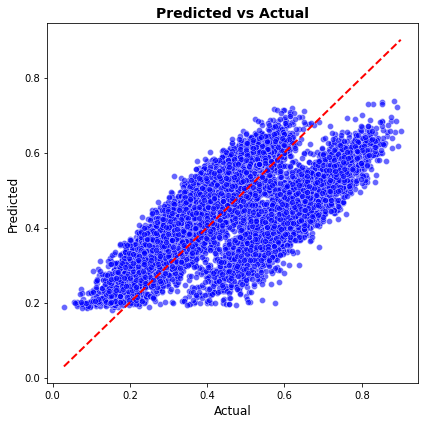


Epoch    26
Train_cost  = 0.0110 | Test_cost  = 0.0111 | Train_score = 0.4425 | Test_score = 0.4385 |
==> EarlyStop patience =  3 | Best test_score: 0.4390


─────────────────────────────────────────────────── 🚀 EPOCH 27 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2418.94it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0111 │
│ MAE    │ 0.0831 │ 0.0824 │
│ RMSE   │ 0.1048 │ 0.1055 │
│ R2     │ 0.4429 │ 0.4385 │
└────────┴────────┴────────┘

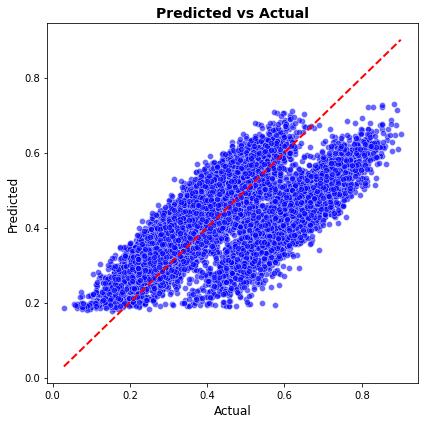


Epoch    27
Train_cost  = 0.0110 | Test_cost  = 0.0111 | Train_score = 0.4429 | Test_score = 0.4385 |
==> EarlyStop patience =  4 | Best test_score: 0.4390


─────────────────────────────────────────────────── 🚀 EPOCH 28 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2709.75it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0111 │
│ MAE    │ 0.0830 │ 0.0859 │
│ RMSE   │ 0.1048 │ 0.1056 │
│ R2     │ 0.4429 │ 0.4381 │
└────────┴────────┴────────┘

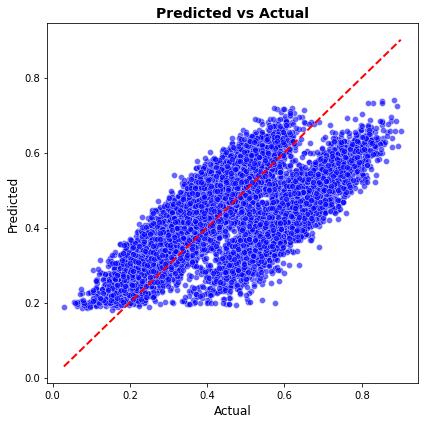


Epoch    28
Train_cost  = 0.0110 | Test_cost  = 0.0111 | Train_score = 0.4429 | Test_score = 0.4381 |
==> EarlyStop patience =  5 | Best test_score: 0.4390


─────────────────────────────────────────────────── 🚀 EPOCH 29 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2353.31it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0111 │
│ MAE    │ 0.0831 │ 0.0856 │
│ RMSE   │ 0.1048 │ 0.1056 │
│ R2     │ 0.4427 │ 0.4384 │
└────────┴────────┴────────┘

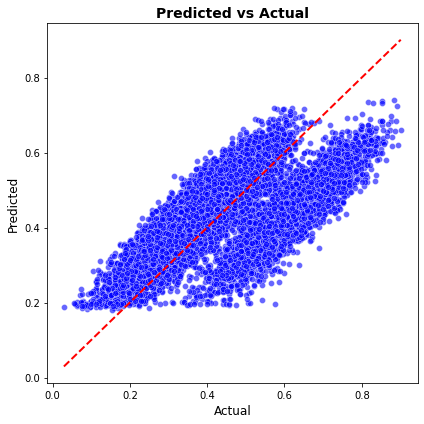


Epoch    29
Train_cost  = 0.0110 | Test_cost  = 0.0111 | Train_score = 0.4427 | Test_score = 0.4384 |
==> EarlyStop patience =  6 | Best test_score: 0.4390


─────────────────────────────────────────────────── 🚀 EPOCH 30 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2521.56it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0112 │
│ MAE    │ 0.0830 │ 0.0871 │
│ RMSE   │ 0.1048 │ 0.1058 │
│ R2     │ 0.4431 │ 0.4362 │
└────────┴────────┴────────┘

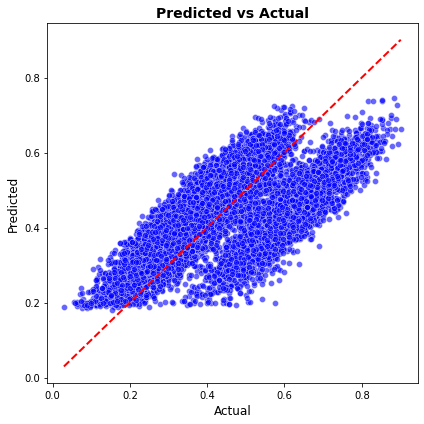


Epoch    30
Train_cost  = 0.0110 | Test_cost  = 0.0112 | Train_score = 0.4431 | Test_score = 0.4362 |
==> EarlyStop patience =  7 | Best test_score: 0.4390


─────────────────────────────────────────────────── 🚀 EPOCH 31 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2489.40it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0111 │
│ MAE    │ 0.0830 │ 0.0848 │
│ RMSE   │ 0.1048 │ 0.1055 │
│ R2     │ 0.4430 │ 0.4393 │
└────────┴────────┴────────┘

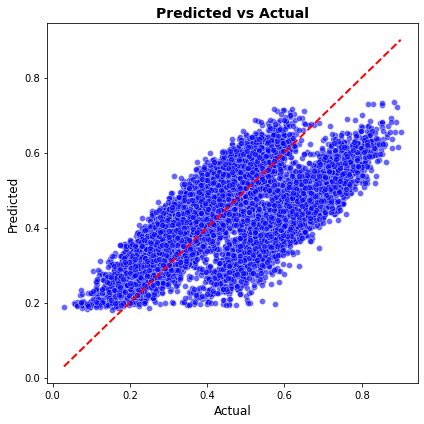


Epoch    31
Train_cost  = 0.0110 | Test_cost  = 0.0111 | Train_score = 0.4430 | Test_score = 0.4393 |


─────────────────────────────────────────────────── 🚀 EPOCH 32 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2504.36it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0111 │
│ MAE    │ 0.0830 │ 0.0834 │
│ RMSE   │ 0.1048 │ 0.1054 │
│ R2     │ 0.4431 │ 0.4395 │
└────────┴────────┴────────┘

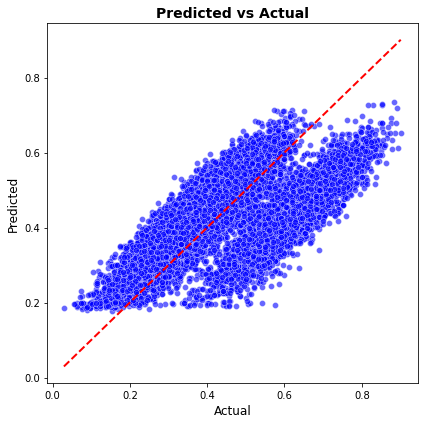


Epoch    32
Train_cost  = 0.0110 | Test_cost  = 0.0111 | Train_score = 0.4431 | Test_score = 0.4395 |


─────────────────────────────────────────────────── 🚀 EPOCH 33 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2478.40it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0111 │
│ MAE    │ 0.0830 │ 0.0830 │
│ RMSE   │ 0.1048 │ 0.1055 │
│ R2     │ 0.4431 │ 0.4392 │
└────────┴────────┴────────┘

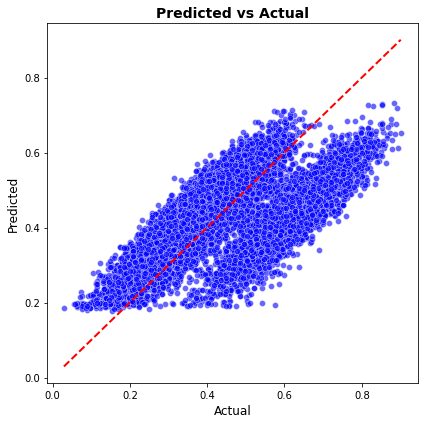


Epoch    33
Train_cost  = 0.0110 | Test_cost  = 0.0111 | Train_score = 0.4431 | Test_score = 0.4392 |
==> EarlyStop patience =  1 | Best test_score: 0.4395


─────────────────────────────────────────────────── 🚀 EPOCH 34 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2379.80it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0111 │
│ MAE    │ 0.0830 │ 0.0844 │
│ RMSE   │ 0.1048 │ 0.1054 │
│ R2     │ 0.4432 │ 0.4396 │
└────────┴────────┴────────┘

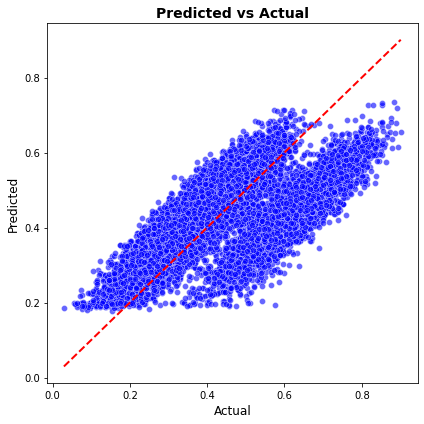


Epoch    34
Train_cost  = 0.0110 | Test_cost  = 0.0111 | Train_score = 0.4432 | Test_score = 0.4396 |


─────────────────────────────────────────────────── 🚀 EPOCH 35 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2521.82it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0111 │
│ MAE    │ 0.0830 │ 0.0848 │
│ RMSE   │ 0.1048 │ 0.1055 │
│ R2     │ 0.4432 │ 0.4394 │
└────────┴────────┴────────┘

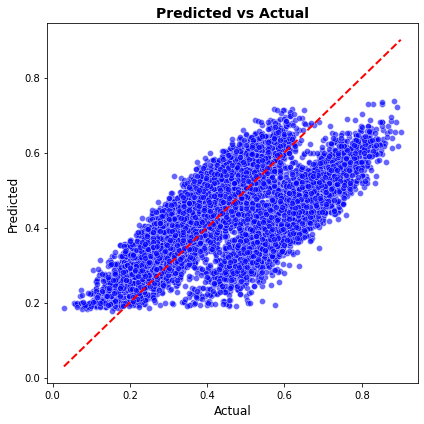


Epoch    35
Train_cost  = 0.0110 | Test_cost  = 0.0111 | Train_score = 0.4432 | Test_score = 0.4394 |
==> EarlyStop patience =  1 | Best test_score: 0.4396


─────────────────────────────────────────────────── 🚀 EPOCH 36 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2534.69it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0111 │
│ MAE    │ 0.0830 │ 0.0841 │
│ RMSE   │ 0.1048 │ 0.1054 │
│ R2     │ 0.4432 │ 0.4397 │
└────────┴────────┴────────┘

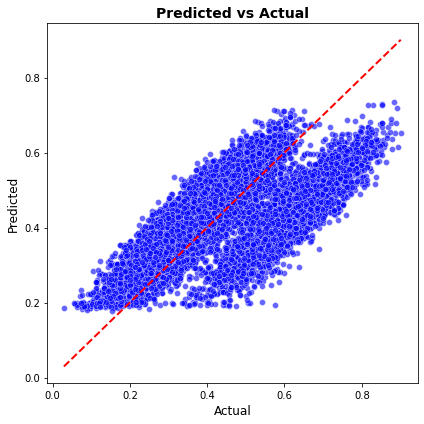


Epoch    36
Train_cost  = 0.0110 | Test_cost  = 0.0111 | Train_score = 0.4432 | Test_score = 0.4397 |


─────────────────────────────────────────────────── 🚀 EPOCH 37 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2633.13it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0111 │
│ MAE    │ 0.0830 │ 0.0823 │
│ RMSE   │ 0.1048 │ 0.1055 │
│ R2     │ 0.4431 │ 0.4386 │
└────────┴────────┴────────┘

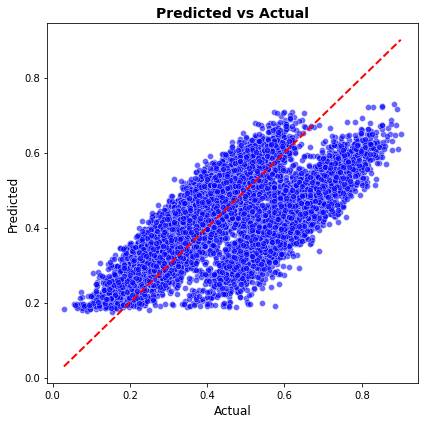


Epoch    37
Train_cost  = 0.0110 | Test_cost  = 0.0111 | Train_score = 0.4431 | Test_score = 0.4386 |
==> EarlyStop patience =  1 | Best test_score: 0.4397


─────────────────────────────────────────────────── 🚀 EPOCH 38 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2363.99it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0111 │
│ MAE    │ 0.0830 │ 0.0836 │
│ RMSE   │ 0.1047 │ 0.1054 │
│ R2     │ 0.4434 │ 0.4397 │
└────────┴────────┴────────┘

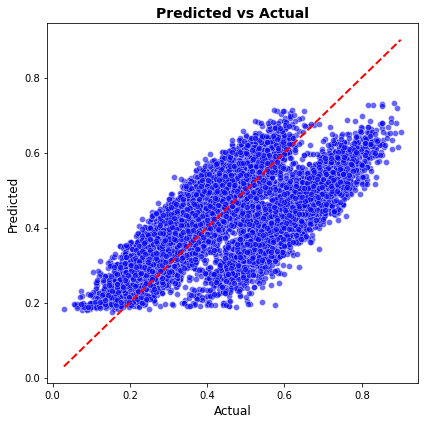


Epoch    38
Train_cost  = 0.0110 | Test_cost  = 0.0111 | Train_score = 0.4434 | Test_score = 0.4397 |


─────────────────────────────────────────────────── 🚀 EPOCH 39 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2545.80it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0111 │
│ MAE    │ 0.0830 │ 0.0827 │
│ RMSE   │ 0.1048 │ 0.1055 │
│ R2     │ 0.4431 │ 0.4392 │
└────────┴────────┴────────┘

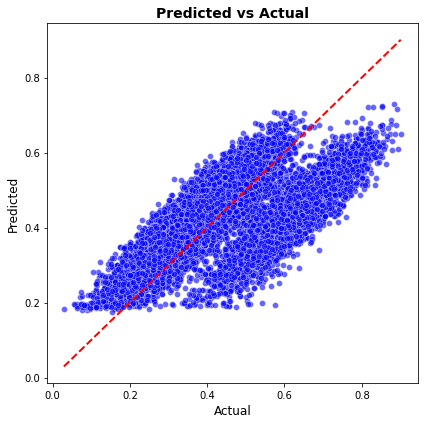


Epoch    39
Train_cost  = 0.0110 | Test_cost  = 0.0111 | Train_score = 0.4431 | Test_score = 0.4392 |
==> EarlyStop patience =  1 | Best test_score: 0.4397


─────────────────────────────────────────────────── 🚀 EPOCH 40 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2330.93it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0111 │
│ MAE    │ 0.0830 │ 0.0829 │
│ RMSE   │ 0.1048 │ 0.1055 │
│ R2     │ 0.4433 │ 0.4394 │
└────────┴────────┴────────┘

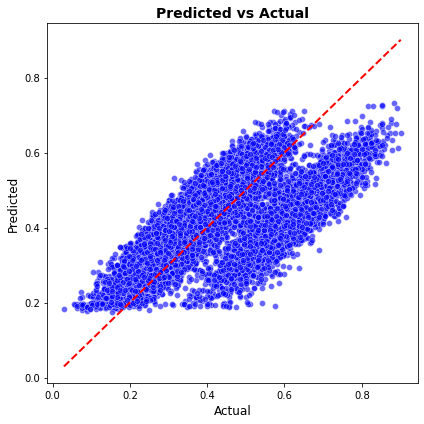


Epoch    40
Train_cost  = 0.0110 | Test_cost  = 0.0111 | Train_score = 0.4433 | Test_score = 0.4394 |


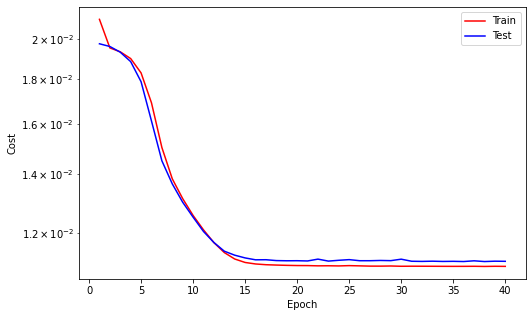

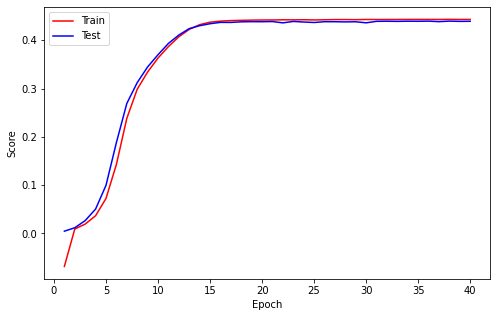

==> EarlyStop patience =  2 | Best test_score: 0.4397


─────────────────────────────────────────────────── 🚀 EPOCH 41 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2556.91it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0111 │
│ MAE    │ 0.0830 │ 0.0832 │
│ RMSE   │ 0.1048 │ 0.1054 │
│ R2     │ 0.4433 │ 0.4395 │
└────────┴────────┴────────┘

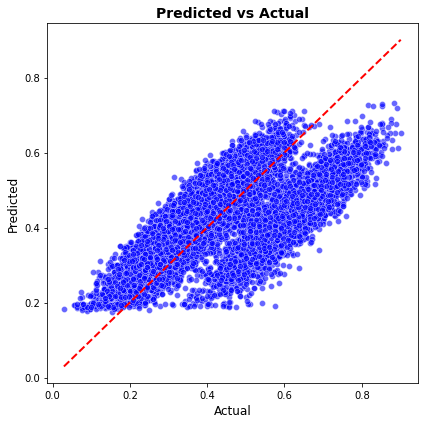


Epoch    41
Train_cost  = 0.0110 | Test_cost  = 0.0111 | Train_score = 0.4433 | Test_score = 0.4395 |
==> EarlyStop patience =  3 | Best test_score: 0.4397


─────────────────────────────────────────────────── 🚀 EPOCH 42 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2350.50it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0111 │
│ MAE    │ 0.0830 │ 0.0855 │
│ RMSE   │ 0.1047 │ 0.1055 │
│ R2     │ 0.4434 │ 0.4388 │
└────────┴────────┴────────┘

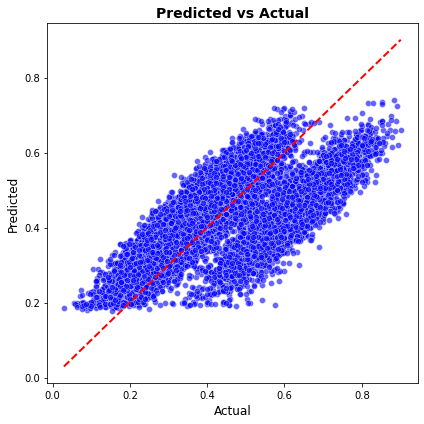


Epoch    42
Train_cost  = 0.0110 | Test_cost  = 0.0111 | Train_score = 0.4434 | Test_score = 0.4388 |
==> EarlyStop patience =  4 | Best test_score: 0.4397


─────────────────────────────────────────────────── 🚀 EPOCH 43 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2517.86it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0112 │
│ MAE    │ 0.0830 │ 0.0816 │
│ RMSE   │ 0.1047 │ 0.1056 │
│ R2     │ 0.4434 │ 0.4377 │
└────────┴────────┴────────┘

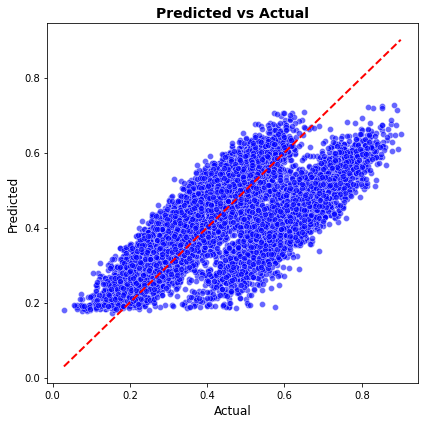


Epoch    43
Train_cost  = 0.0110 | Test_cost  = 0.0112 | Train_score = 0.4434 | Test_score = 0.4377 |
==> EarlyStop patience =  5 | Best test_score: 0.4397


─────────────────────────────────────────────────── 🚀 EPOCH 44 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2531.16it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0111 │
│ MAE    │ 0.0830 │ 0.0842 │
│ RMSE   │ 0.1048 │ 0.1054 │
│ R2     │ 0.4433 │ 0.4398 │
└────────┴────────┴────────┘

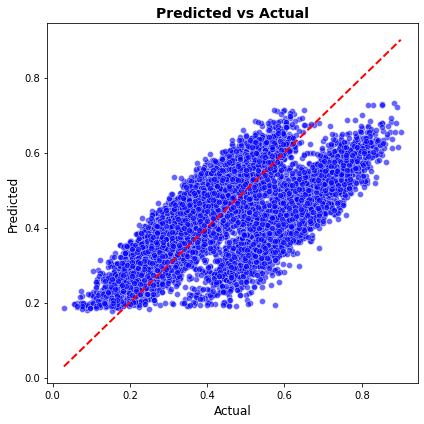


Epoch    44
Train_cost  = 0.0110 | Test_cost  = 0.0111 | Train_score = 0.4433 | Test_score = 0.4398 |


─────────────────────────────────────────────────── 🚀 EPOCH 45 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2492.72it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0111 │
│ MAE    │ 0.0830 │ 0.0841 │
│ RMSE   │ 0.1047 │ 0.1054 │
│ R2     │ 0.4436 │ 0.4397 │
└────────┴────────┴────────┘

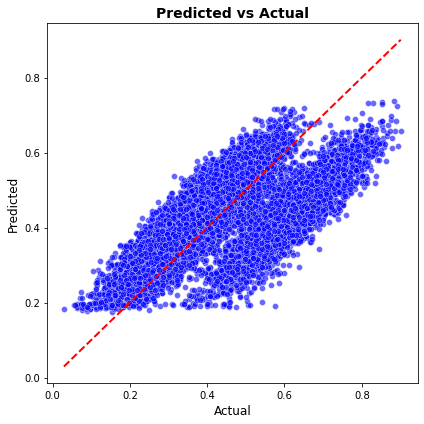


Epoch    45
Train_cost  = 0.0110 | Test_cost  = 0.0111 | Train_score = 0.4436 | Test_score = 0.4397 |
==> EarlyStop patience =  1 | Best test_score: 0.4398


─────────────────────────────────────────────────── 🚀 EPOCH 46 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2219.48it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0111 │
│ MAE    │ 0.0829 │ 0.0819 │
│ RMSE   │ 0.1047 │ 0.1056 │
│ R2     │ 0.4436 │ 0.4383 │
└────────┴────────┴────────┘

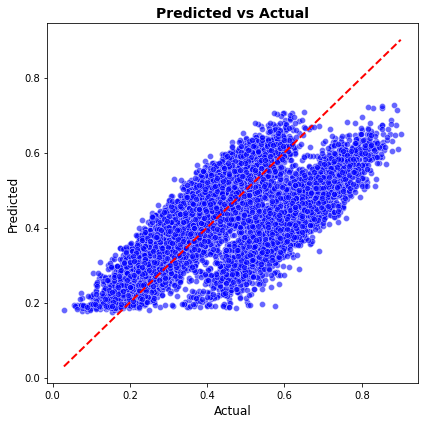


Epoch    46
Train_cost  = 0.0110 | Test_cost  = 0.0111 | Train_score = 0.4436 | Test_score = 0.4383 |
==> EarlyStop patience =  2 | Best test_score: 0.4398


─────────────────────────────────────────────────── 🚀 EPOCH 47 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2380.14it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0112 │
│ MAE    │ 0.0830 │ 0.0817 │
│ RMSE   │ 0.1047 │ 0.1056 │
│ R2     │ 0.4435 │ 0.4379 │
└────────┴────────┴────────┘

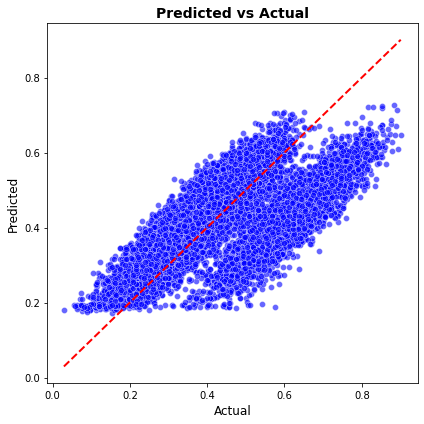


Epoch    47
Train_cost  = 0.0110 | Test_cost  = 0.0112 | Train_score = 0.4435 | Test_score = 0.4379 |
==> EarlyStop patience =  3 | Best test_score: 0.4398


─────────────────────────────────────────────────── 🚀 EPOCH 48 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2550.02it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0111 │
│ MAE    │ 0.0829 │ 0.0836 │
│ RMSE   │ 0.1047 │ 0.1054 │
│ R2     │ 0.4436 │ 0.4399 │
└────────┴────────┴────────┘

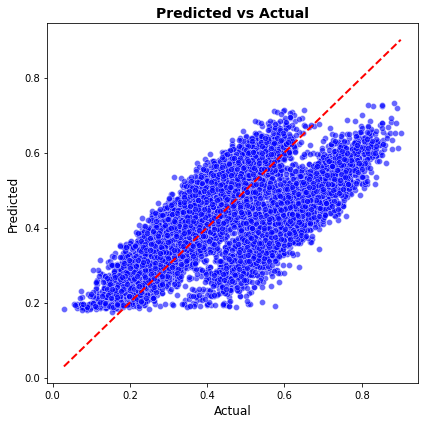


Epoch    48
Train_cost  = 0.0110 | Test_cost  = 0.0111 | Train_score = 0.4436 | Test_score = 0.4399 |


─────────────────────────────────────────────────── 🚀 EPOCH 49 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2279.32it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0111 │
│ MAE    │ 0.0829 │ 0.0853 │
│ RMSE   │ 0.1047 │ 0.1055 │
│ R2     │ 0.4436 │ 0.4392 │
└────────┴────────┴────────┘

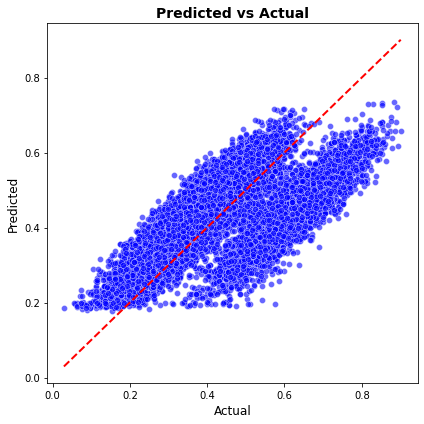


Epoch    49
Train_cost  = 0.0110 | Test_cost  = 0.0111 | Train_score = 0.4436 | Test_score = 0.4392 |
==> EarlyStop patience =  1 | Best test_score: 0.4399


─────────────────────────────────────────────────── 🚀 EPOCH 50 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2505.90it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0112 │
│ MAE    │ 0.0829 │ 0.0873 │
│ RMSE   │ 0.1047 │ 0.1058 │
│ R2     │ 0.4436 │ 0.4361 │
└────────┴────────┴────────┘

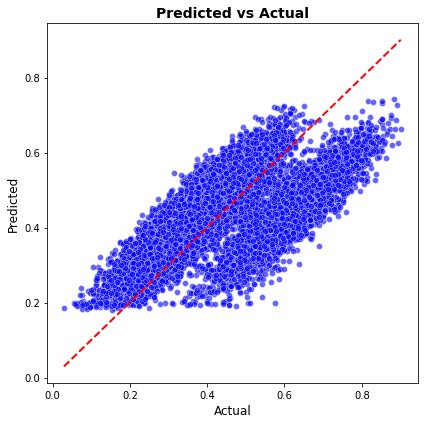


Epoch    50
Train_cost  = 0.0110 | Test_cost  = 0.0112 | Train_score = 0.4436 | Test_score = 0.4361 |
==> EarlyStop patience =  2 | Best test_score: 0.4399


─────────────────────────────────────────────────── 🚀 EPOCH 51 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2438.33it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0111 │
│ MAE    │ 0.0829 │ 0.0856 │
│ RMSE   │ 0.1047 │ 0.1055 │
│ R2     │ 0.4437 │ 0.4388 │
└────────┴────────┴────────┘

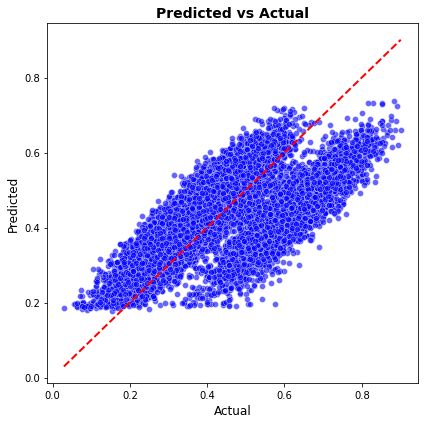


Epoch    51
Train_cost  = 0.0110 | Test_cost  = 0.0111 | Train_score = 0.4437 | Test_score = 0.4388 |
==> EarlyStop patience =  3 | Best test_score: 0.4399


─────────────────────────────────────────────────── 🚀 EPOCH 52 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2492.49it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0111 │
│ MAE    │ 0.0830 │ 0.0851 │
│ RMSE   │ 0.1047 │ 0.1055 │
│ R2     │ 0.4433 │ 0.4392 │
└────────┴────────┴────────┘

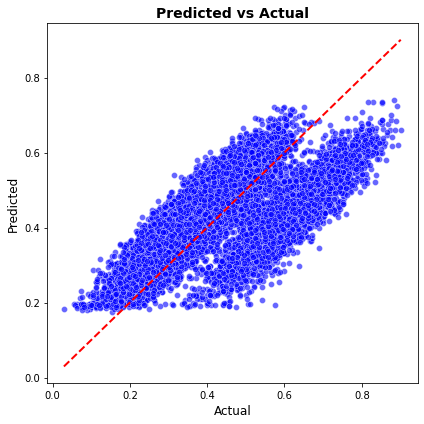


Epoch    52
Train_cost  = 0.0110 | Test_cost  = 0.0111 | Train_score = 0.4433 | Test_score = 0.4392 |
==> EarlyStop patience =  4 | Best test_score: 0.4399


─────────────────────────────────────────────────── 🚀 EPOCH 53 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2461.80it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0111 │
│ MAE    │ 0.0829 │ 0.0836 │
│ RMSE   │ 0.1047 │ 0.1054 │
│ R2     │ 0.4436 │ 0.4399 │
└────────┴────────┴────────┘

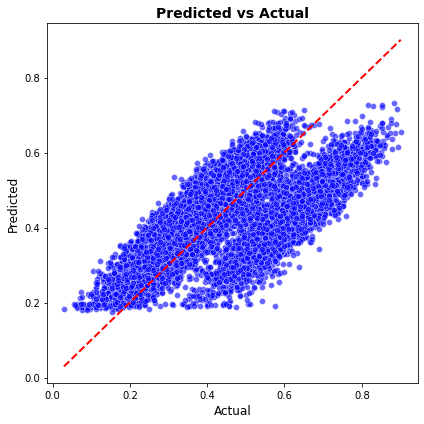


Epoch    53
Train_cost  = 0.0110 | Test_cost  = 0.0111 | Train_score = 0.4436 | Test_score = 0.4399 |
==> EarlyStop patience =  5 | Best test_score: 0.4399


─────────────────────────────────────────────────── 🚀 EPOCH 54 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2508.31it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0111 │
│ MAE    │ 0.0830 │ 0.0834 │
│ RMSE   │ 0.1047 │ 0.1054 │
│ R2     │ 0.4435 │ 0.4398 │
└────────┴────────┴────────┘

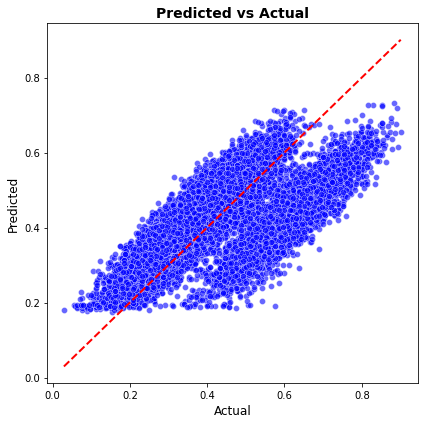


Epoch    54
Train_cost  = 0.0110 | Test_cost  = 0.0111 | Train_score = 0.4435 | Test_score = 0.4398 |
==> EarlyStop patience =  6 | Best test_score: 0.4399


─────────────────────────────────────────────────── 🚀 EPOCH 55 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2373.88it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0111 │
│ MAE    │ 0.0829 │ 0.0846 │
│ RMSE   │ 0.1047 │ 0.1054 │
│ R2     │ 0.4438 │ 0.4398 │
└────────┴────────┴────────┘

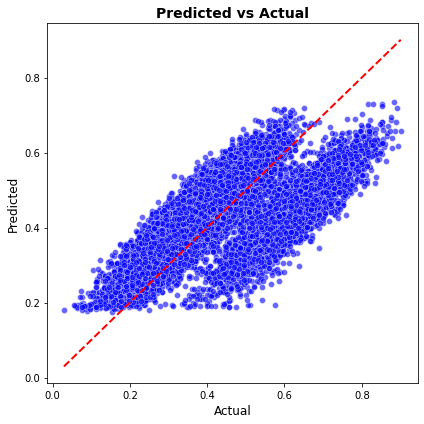


Epoch    55
Train_cost  = 0.0110 | Test_cost  = 0.0111 | Train_score = 0.4438 | Test_score = 0.4398 |
==> EarlyStop patience =  7 | Best test_score: 0.4399


─────────────────────────────────────────────────── 🚀 EPOCH 56 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2454.04it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0111 │
│ MAE    │ 0.0829 │ 0.0840 │
│ RMSE   │ 0.1047 │ 0.1054 │
│ R2     │ 0.4438 │ 0.4400 │
└────────┴────────┴────────┘

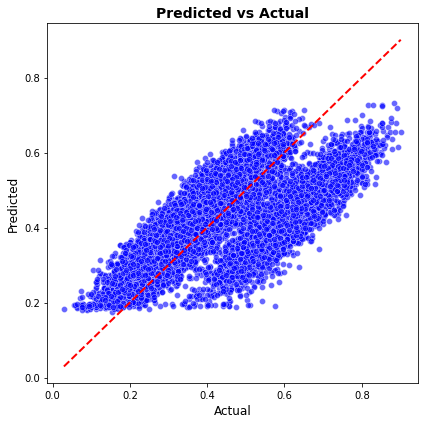


Epoch    56
Train_cost  = 0.0110 | Test_cost  = 0.0111 | Train_score = 0.4438 | Test_score = 0.4400 |


─────────────────────────────────────────────────── 🚀 EPOCH 57 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2371.90it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0111 │
│ MAE    │ 0.0829 │ 0.0848 │
│ RMSE   │ 0.1047 │ 0.1054 │
│ R2     │ 0.4437 │ 0.4396 │
└────────┴────────┴────────┘

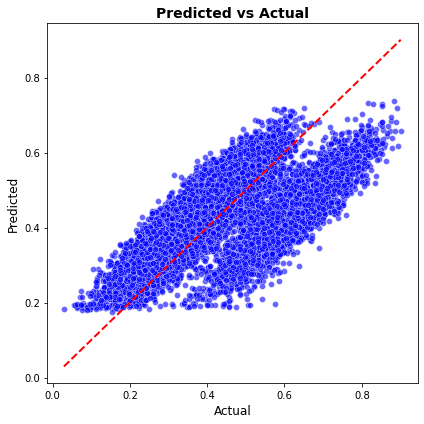


Epoch    57
Train_cost  = 0.0110 | Test_cost  = 0.0111 | Train_score = 0.4437 | Test_score = 0.4396 |
==> EarlyStop patience =  1 | Best test_score: 0.4400


─────────────────────────────────────────────────── 🚀 EPOCH 58 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2498.40it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0111 │
│ MAE    │ 0.0829 │ 0.0846 │
│ RMSE   │ 0.1047 │ 0.1054 │
│ R2     │ 0.4439 │ 0.4397 │
└────────┴────────┴────────┘

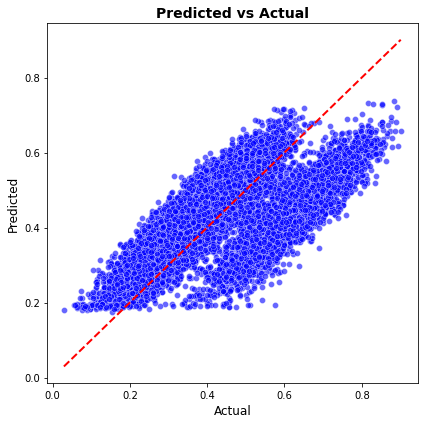


Epoch    58
Train_cost  = 0.0110 | Test_cost  = 0.0111 | Train_score = 0.4439 | Test_score = 0.4397 |
==> EarlyStop patience =  2 | Best test_score: 0.4400


─────────────────────────────────────────────────── 🚀 EPOCH 59 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2507.01it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0111 │
│ MAE    │ 0.0829 │ 0.0847 │
│ RMSE   │ 0.1047 │ 0.1054 │
│ R2     │ 0.4438 │ 0.4397 │
└────────┴────────┴────────┘

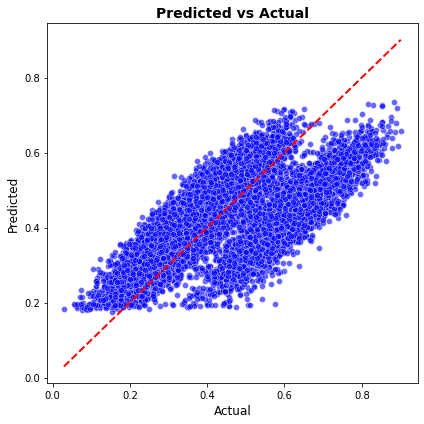


Epoch    59
Train_cost  = 0.0110 | Test_cost  = 0.0111 | Train_score = 0.4438 | Test_score = 0.4397 |
==> EarlyStop patience =  3 | Best test_score: 0.4400


─────────────────────────────────────────────────── 🚀 EPOCH 60 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2461.93it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0111 │
│ MAE    │ 0.0829 │ 0.0861 │
│ RMSE   │ 0.1047 │ 0.1056 │
│ R2     │ 0.4437 │ 0.4381 │
└────────┴────────┴────────┘

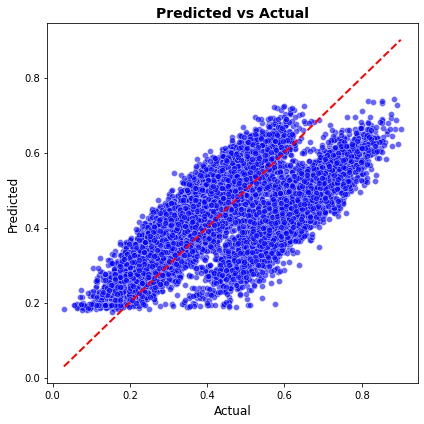


Epoch    60
Train_cost  = 0.0110 | Test_cost  = 0.0111 | Train_score = 0.4437 | Test_score = 0.4381 |


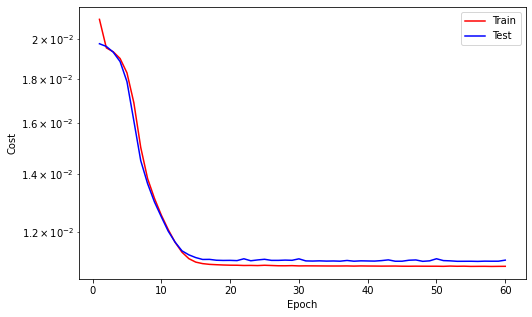

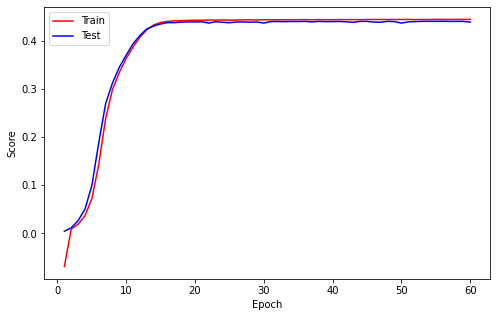

==> EarlyStop patience =  4 | Best test_score: 0.4400


─────────────────────────────────────────────────── 🚀 EPOCH 61 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2487.72it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0111 │
│ MAE    │ 0.0829 │ 0.0852 │
│ RMSE   │ 0.1047 │ 0.1055 │
│ R2     │ 0.4436 │ 0.4392 │
└────────┴────────┴────────┘

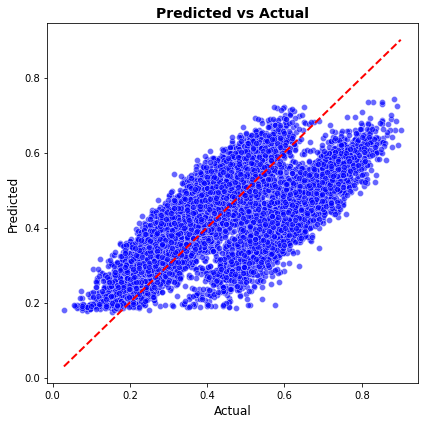


Epoch    61
Train_cost  = 0.0110 | Test_cost  = 0.0111 | Train_score = 0.4436 | Test_score = 0.4392 |
==> EarlyStop patience =  5 | Best test_score: 0.4400


─────────────────────────────────────────────────── 🚀 EPOCH 62 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2283.94it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0111 │
│ MAE    │ 0.0829 │ 0.0842 │
│ RMSE   │ 0.1047 │ 0.1054 │
│ R2     │ 0.4438 │ 0.4400 │
└────────┴────────┴────────┘

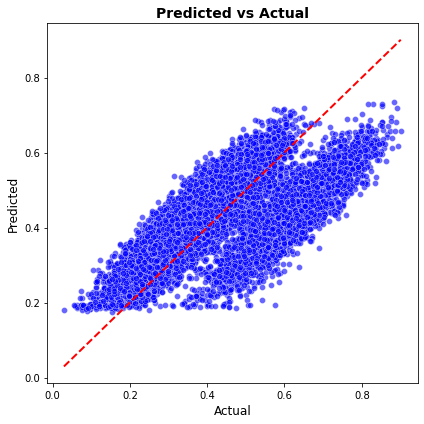


Epoch    62
Train_cost  = 0.0110 | Test_cost  = 0.0111 | Train_score = 0.4438 | Test_score = 0.4400 |
==> EarlyStop patience =  6 | Best test_score: 0.4400


─────────────────────────────────────────────────── 🚀 EPOCH 63 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2335.72it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0111 │
│ MAE    │ 0.0829 │ 0.0825 │
│ RMSE   │ 0.1047 │ 0.1055 │
│ R2     │ 0.4439 │ 0.4394 │
└────────┴────────┴────────┘

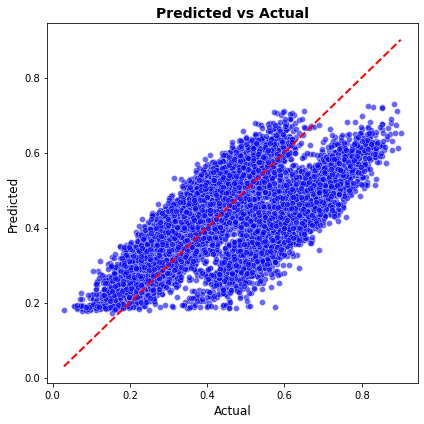


Epoch    63
Train_cost  = 0.0110 | Test_cost  = 0.0111 | Train_score = 0.4439 | Test_score = 0.4394 |
==> EarlyStop patience =  7 | Best test_score: 0.4400


─────────────────────────────────────────────────── 🚀 EPOCH 64 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2408.15it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0111 │
│ MAE    │ 0.0829 │ 0.0829 │
│ RMSE   │ 0.1047 │ 0.1054 │
│ R2     │ 0.4440 │ 0.4397 │
└────────┴────────┴────────┘

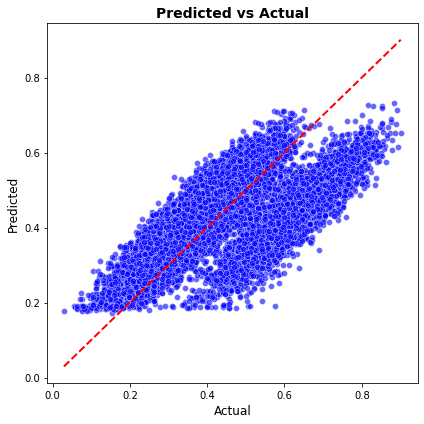


Epoch    64
Train_cost  = 0.0110 | Test_cost  = 0.0111 | Train_score = 0.4440 | Test_score = 0.4397 |
==> EarlyStop patience =  8 | Best test_score: 0.4400


─────────────────────────────────────────────────── 🚀 EPOCH 65 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2457.14it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0112 │
│ MAE    │ 0.0829 │ 0.0816 │
│ RMSE   │ 0.1047 │ 0.1056 │
│ R2     │ 0.4438 │ 0.4379 │
└────────┴────────┴────────┘

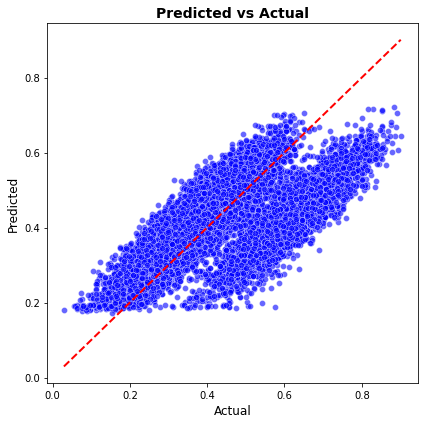


Epoch    65
Train_cost  = 0.0110 | Test_cost  = 0.0112 | Train_score = 0.4438 | Test_score = 0.4379 |
==> EarlyStop patience =  9 | Best test_score: 0.4400


─────────────────────────────────────────────────── 🚀 EPOCH 66 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 2355.09it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.0110 │ 0.0112 │
│ MAE    │ 0.0829 │ 0.0816 │
│ RMSE   │ 0.1047 │ 0.1056 │
│ R2     │ 0.4436 │ 0.4379 │
└────────┴────────┴────────┘

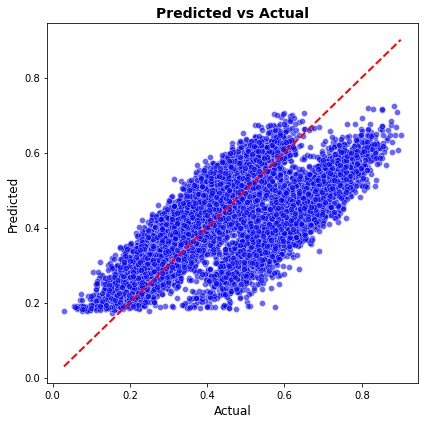


Epoch    66
Train_cost  = 0.0110 | Test_cost  = 0.0112 | Train_score = 0.4436 | Test_score = 0.4379 |
==> EarlyStop patience = 10 | Best test_score: 0.4400
==> Execute Early Stopping at epoch: 66 | Best test_score: 0.4400
==> Best model is saved at regresi/one-d/diabetes_dataset/


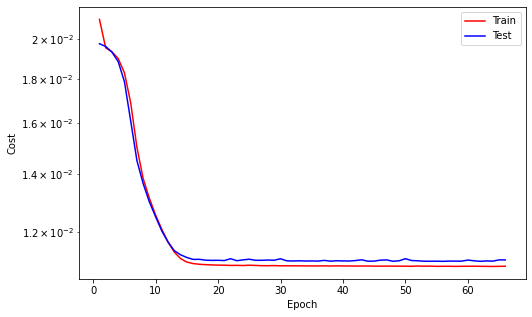

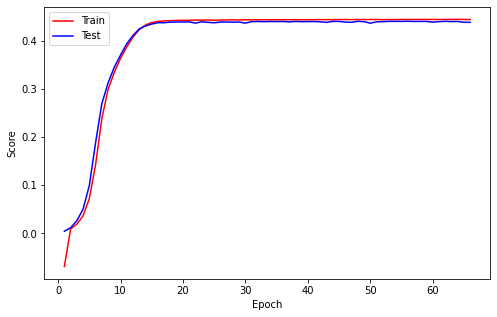

⏹️ Training dihentikan oleh early stopping.

In [15]:
from train_and_evaluate import train_and_evaluate_regression

train_and_evaluate_regression(
    model=model,
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optim=optim,
    config=config,
    device=device,        
    callback=callback,
    show_detail=True
)

# Evaluate

📊 Evaluasi Model Regresi 
┏━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃ Metrik        ┃  Nilai ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━┩
│ 💥 Loss (avg) │ 0.0111 │
│ 📉 MAE        │ 0.0840 │
│ 📉 MSE        │ 0.0111 │
│ 📉 RMSE       │ 0.1054 │
│ 📈 R² Score   │ 0.4400 │
└───────────────┴────────┘

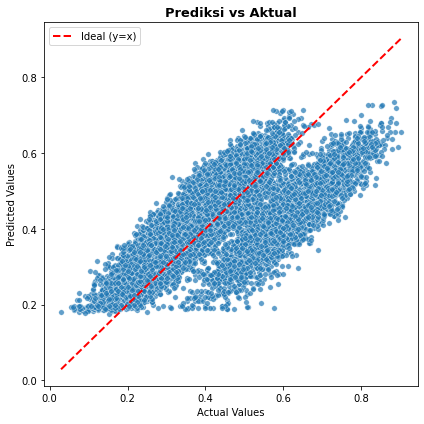

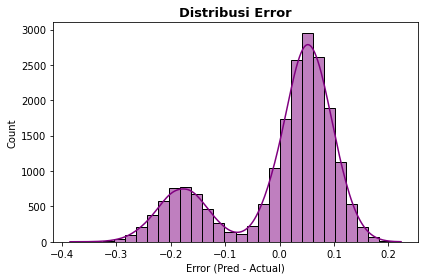

In [17]:
from evaluate import evaluate_regression

hsl = evaluate_regression(
    model=model,
    dataloader=test_loader,
    criterion=criterion,
    device=device,
    dimension='1d',
    
)

In [18]:
hsl['df'].head(200)

,Target,Prediksi,Error,Error (%)
0,0.3566,0.4046,0.0480,13.470000
1,0.1333,0.2412,0.1079,80.919998
2,0.4667,0.5121,0.0454,9.730000
3,0.4822,0.5535,0.0713,14.780000
4,0.4589,0.2293,-0.2296,-50.029999
...,...,...,...,...
195,0.2837,0.2574,-0.0263,-9.280000
196,0.2124,0.3047,0.0923,43.430000
197,0.4233,0.4670,0.0437,10.330000
198,0.2961,0.3573,0.0612,20.670000


# Pengaplikasian

In [ ]:
#!pip install ipywidgets
#!jupyter nbextension enable --py widgetsnbextension

In [19]:
import torch, json
from torch import optim, nn
from class_lib import Model1DPure
import joblib
import pandas as pd


# Load Config
try:
    config = torch.load(root_folder + "configs.pth", map_location="cpu", weights_only=False)
except:
    config = torch.load(root_folder + "configs.pth", map_location="cpu")

#Load Weights
weights= torch.load(root_folder + "weights_best.pth", map_location="cpu")

#Load Label Mapping
with open(root_folder + "label_mappings.json", "r") as f:
    label_mapping = json.load(f)


model = Model1DPure(input_dim=config.input_dim, hidden_dims=config.hidden_dims, output_dim=config.output_dim, dropout=config.dropout, activation=config.activation)
model.load_state_dict(weights)
model.eval() 

Model1DPure(
  (model): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.0, inplace=False)
    (6): Linear(in_features=16, out_features=8, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.0, inplace=False)
    (9): Linear(in_features=8, out_features=4, bias=True)
    (10): ReLU()
    (11): Dropout(p=0.0, inplace=False)
    (12): Linear(in_features=4, out_features=1, bias=True)
  )
)

In [20]:
from aplokator import MultiClassPredictor

import os
import torch
import torch.nn.functional as F
import pandas as pd
import joblib
import ipywidgets as widgets
from IPython.display import display, clear_output

class RegressionPredictor:
    """
    Class untuk membuat form input dan melakukan prediksi REGRESI dengan model PyTorch.
    
    Args:
        model (nn.Module): Model PyTorch yang sudah diload.
        config: Konfigurasi model (input_dim, hidden_dims, output_dim, dll).
        label_mapping (dict): Mapping label untuk kolom kategorikal (opsional).
        scaler_folder (str): Folder tempat file scaler .pkl berada.
        dimension (str): '1d', '2d', atau '3d' sesuai model.
    """
    
    def __init__(self, model, config, label_mapping=None, scaler_folder=None, dimension='1d'):
        self.model = model
        self.model.eval()
        self.config = config
        self.label_mapping = label_mapping or {}
        self.scaler_folder = scaler_folder
        self.dimension = dimension
        
        # Gabungkan semua feature_cols otomatis dari config
        self.feature_cols = []
        for key, value in vars(self.config).items():
            if key.startswith("feature") and key.endswith("_cols"):
                if isinstance(value, list):
                    self.feature_cols.extend(value)
        
        self.numeric_cols = [c for c in self.feature_cols if not c.startswith("label_")]
        self.radios, self.inputs = [], []
        self._build_widgets()
        self._display_form()

    # ==================== INTERNAL: Build widgets ====================
    def _build_widgets(self):
        ultra_compact = widgets.Layout(width='90%', margin='2px 0')
        
        for c in self.feature_cols:
            if c.startswith("label_"):
                label_name = c.replace("label_", "")
                options = self.label_mapping.get(label_name, [])
                radio = widgets.RadioButtons(
                    options=options,
                    description=f'🎯 {label_name}:',
                    disabled=False,
                    layout=ultra_compact,
                    style={'description_width': '120px'}
                )
                self.radios.append((c, radio))
            else:
                placeholder = f"Value for {c}"
                if self.scaler_folder:
                    scaler_path = os.path.join(self.scaler_folder, f'scaler_{c}.pkl')
                    if os.path.exists(scaler_path):
                        scaler_col = joblib.load(scaler_path)
                        placeholder += f" (min:{scaler_col.data_min_[0]} | max:{scaler_col.data_max_[0]})"
                inputan = widgets.Text(
                    value='',
                    placeholder=placeholder,
                    description=f'📊 {c}:',
                    disabled=False,
                    layout=ultra_compact,
                    style={'description_width': '320px'}
                )
                self.inputs.append((c, inputan))
        
        # Tombol & output
        self.btn = widgets.Button(
            description='🚀 Predict',
            button_style='primary',
            layout=widgets.Layout(width='120px', margin='8px 0')
        )
        self.out_w = widgets.Output()
        self.btn.on_click(self._predict_click)

    # ==================== INTERNAL: Fungsi prediksi tombol ====================
    def _predict_click(self, b):
        with self.out_w:
            clear_output()
            print("📋 INPUT DATA")
            print("─" * 30)
            
            # Ambil semua nilai input
            data_dict = {col: r.value for col, r in self.radios}
            for col, i in self.inputs:
                val = i.value.strip()
                try:
                    val = float(val)
                except:
                    pass
                data_dict[col] = val if val != '' else None
            
            df_input = pd.DataFrame([data_dict])
            df_input = df_input[self.feature_cols]
            display(df_input)
            
            # Scaling numerik
            df_scaled = df_input.copy()
            if self.scaler_folder:
                for col in self.numeric_cols:
                    scaler_path = os.path.join(self.scaler_folder, f'scaler_{col}.pkl')
                    if os.path.exists(scaler_path):
                        scaler_col = joblib.load(scaler_path)
                        df_scaled[[col]] = scaler_col.transform(df_input[[col]])
                        print(f"✅ '{col}' scaled (min:{scaler_col.data_min_[0]} | max:{scaler_col.data_max_[0]})")
            
            print("\n⚙️ DATA SETELAH SCALING")
            print("─" * 30)
            display(df_scaled)
            
            # Prediksi
            with torch.no_grad():
                if self.dimension == '1d':
                    X = torch.tensor(df_scaled.values, dtype=torch.float32)
                    output = self.model(X)
                elif self.dimension == '2d':
                    X1 = torch.tensor(df_scaled[self.config.feature_1_cols].values, dtype=torch.float32)
                    X2 = torch.tensor(df_scaled[self.config.feature_2_cols].values, dtype=torch.float32)
                    output = self.model(X1, X2)
                elif self.dimension == '3d':
                    X1 = torch.tensor(df_scaled[self.config.feature_1_cols].values, dtype=torch.float32)
                    X2 = torch.tensor(df_scaled[self.config.feature_2_cols].values, dtype=torch.float32)
                    X3 = torch.tensor(df_scaled[self.config.feature_3_cols].values, dtype=torch.float32)
                    output = self.model(X1, X2, X3)
                else:
                    raise ValueError("dimension harus '1d', '2d', atau '3d'")
            
            pred_value = output.cpu().numpy().flatten()[0]
            print("\n✅ HASIL PREDIKSI")
            print("─" * 30)
            print(f"📈 Prediksi nilai kontinu: \033[1;32m{pred_value:.4f}\033[0m")
    
    # ==================== Tampilkan form ====================
    def _display_form(self):
        MINIMAL_STYLE = """
        <style>
        .minimal-container { background: #f8f9fa; padding: 12px; border-radius: 6px; border: 1px solid #dee2e6; }
        .minimal-item { margin: 3px 0; }
        .radio-label { font-weight: bold; color: #333; }
        .input-label { font-weight: bold; color: #555; }
        </style>
        """
        display(widgets.HTML(value=MINIMAL_STYLE))
        form_widgets = [w for _, w in self.radios] + [w for _, w in self.inputs] + [self.btn, self.out_w]
        minimal_form = widgets.VBox(form_widgets, layout=widgets.Layout(padding='8px'))
        display(minimal_form)


predictor = RegressionPredictor(
    model=model,
    config=config,
    label_mapping=label_mapping,
    scaler_folder=root_folder,
)

HTML(value='\n        <style>\n        .minimal-container { background: #f8f9fa; padding: 12px; border-radius:…